<div align="center">

<img src="https://storage.googleapis.com/kaggle-media/competitions/Kaggle/3236/kaggle-logo-transparent.png" width="86" alt="Kaggle">

# Predicting Smartphone Addiction
**A Level-1 Stacking architecture using Optuna-optimised gradient boosting to classify behavioural usage thresholds.**

<br>

[![Author](https://img.shields.io/badge/Author-Amey_Thakur-0969DA)](https://www.kaggle.com/ameythakur20) [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39)](https://orcid.org/0000-0001-5644-1575)

<br>

<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open in Kaggle"></a>

</div>

<br>

---

## 1. Problem Formulation

The Playground Series (S6E8) objective is to predict the probability of smartphone addiction (`addicted_label`) using tabular behavioural metrics. The evaluation metric is the **Area Under the ROC Curve (AUC)**. As a low-dimensional tabular dataset, the primary constraint is correctly mapping non-linear decision boundaries across skewed feature distributions without relying on parameter-heavy deep learning architectures.

This notebook implements a comprehensive machine learning pipeline, focusing on distribution normalisation via rank transformations and a robust Level-1 Stacking ensemble to maximise Out-Of-Fold (OOF) generalisation.

<br>

---

## 2. Environment Initialisation

Global seeds are enforced to guarantee deterministic pseudo-random number generation across the cross-validation splits and boosting architectures.

<br>

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# Gradient Boosters
from lightgbm import LGBMClassifier, plot_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Kaggle Toolbox
sys.path.append("../../Kaggle Toolbox")
import kaggle_toolbox as tb

SEED = 42
tb.seed_everything(SEED)

DATA_DIR = "."
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

[toolbox] All seeds locked to 42


<br>

---

## 3. Data Ingestion & Memory Management

Integer and float precisions are downcast safely to prevent memory exhaustion during parallel boosting iterations.

<br>

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Original Train shape: {train.shape}")

train = tb.reduce_mem_usage(train)
test = tb.reduce_mem_usage(test)

_ = tb.missing_report(train)

Original Train shape: (5000, 9)
[toolbox] Memory: 0.6 MB -> 0.1 MB (81.7% reduction)
[toolbox] Memory: 0.1 MB -> 0.0 MB (81.0% reduction)
[toolbox] 1 column(s) with missing values:


<br>

---

## 4. Exploratory Data Analysis

### 4.1 Feature Correlation
A correlation matrix evaluates multicollinearity between continuous behavioural inputs.

<br>

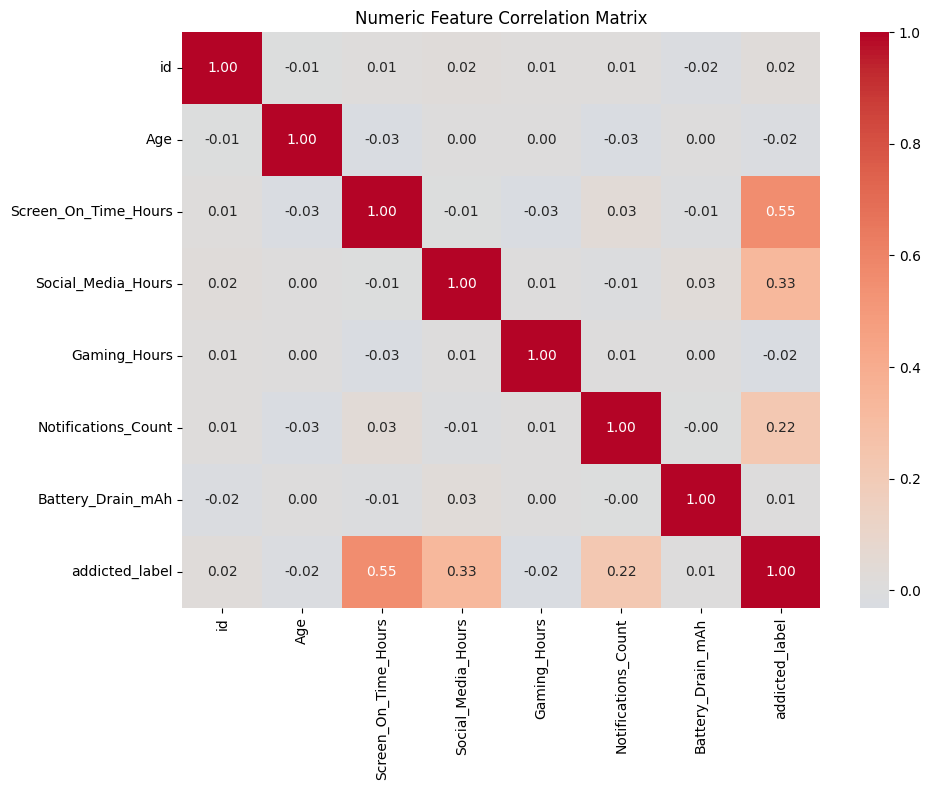

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

<br>

### 4.2 Distribution Density (Violin Plots)
Violin plots isolate the probability density of critical features across the binary target classes, illustrating the variance in median usage.

<br>

/var/folders/ll/2bldbpx16qzc3s4bfy37tz740000gn/T/ipykernel_18391/2662837960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/ll/2bldbpx16qzc3s4bfy37tz740000gn/T/ipykernel_18391/2662837960.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


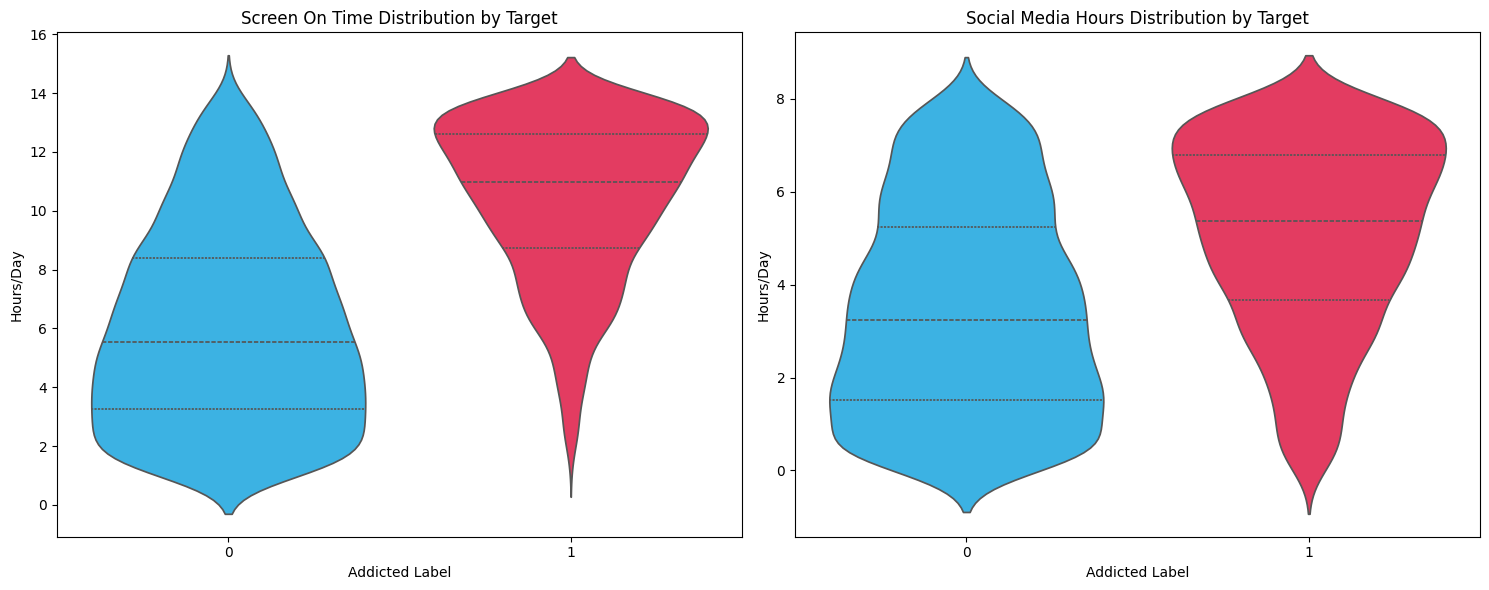

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

sns.violinplot(
    data=train, x="addicted_label", y="Screen_On_Time_Hours", 
    ax=ax1, palette=["#20BEFF", "#FF2052"], inner="quartile"
)
ax1.set_title("Screen On Time Distribution by Target")
ax1.set_xlabel("Addicted Label")
ax1.set_ylabel("Hours/Day")

sns.violinplot(
    data=train, x="addicted_label", y="Social_Media_Hours", 
    ax=ax2, palette=["#20BEFF", "#FF2052"], inner="quartile"
)
ax2.set_title("Social Media Hours Distribution by Target")
ax2.set_xlabel("Addicted Label")
ax2.set_ylabel("Hours/Day")

plt.tight_layout()
plt.show()

<br>

---

## 5. Feature Engineering & Rank Transformation

Gradient boosting architectures natively split on absolute thresholds, making them vulnerable to severe outliers. Applying a rank transformation to skewed variables forces a uniform distribution, allowing deeper, more stable splits. Missing values are flagged explicitly as a structural indicator.

<br>

In [5]:
def engineer_features(df):
    df_feat = df.copy()
    
    # 1. Structural Missingness
    df_feat["Social_Media_Missing"] = df_feat["Social_Media_Hours"].isna().astype("int8")
    df_feat["Social_Media_Hours"] = df_feat["Social_Media_Hours"].fillna(df_feat["Social_Media_Hours"].median())
    
    # 2. Rank Transformations for Skewed Features
    df_feat["Notifications_Rank"] = df_feat["Notifications_Count"].rank(method="dense", pct=True)
    df_feat["Battery_Drain_Rank"] = df_feat["Battery_Drain_mAh"].rank(method="dense", pct=True)
    
    # 3. Categorical Casts
    df_feat["Gender"] = df_feat["Gender"].astype("category")
    
    return df_feat

with tb.timer("Feature Engineering"):
    train_feat = engineer_features(train)
    test_feat = engineer_features(test)

FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label"]]
TARGET = "addicted_label"


[toolbox] Feature Engineering: 0.0s


<br>

---

## 6. Level-0 Base Learners

A 5-Fold Stratified Cross-Validation protocol guarantees the class proportion remains identical across training splits. Three diverse boosting architectures are fit to generate Out-Of-Fold (OOF) predictions.

<br>

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

models = {
    "LightGBM": LGBMClassifier(random_state=SEED, n_estimators=500, learning_rate=0.03, colsample_bytree=0.8, verbose=-1),
    "XGBoost": XGBClassifier(random_state=SEED, n_estimators=500, learning_rate=0.03, colsample_bytree=0.8, enable_categorical=True, eval_metric="auc"),
    "CatBoost": CatBoostClassifier(random_state=SEED, iterations=500, learning_rate=0.03, verbose=0, cat_features=["Gender"])
}

oof_matrix = np.zeros((len(train_feat), len(models)))
test_matrix = np.zeros((len(test_feat), len(models)))

# Store trained LightGBM models for feature importance extraction later
lgb_models = []

for i, (name, model) in enumerate(models.items()):
    with tb.timer(f"Training {name} OOF"):
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_feat[FEATURES], train_feat[TARGET])):
            
            X_train, y_train = train_feat[FEATURES].iloc[train_idx], train_feat[TARGET].iloc[train_idx]
            X_val, y_val = train_feat[FEATURES].iloc[val_idx], train_feat[TARGET].iloc[val_idx]
            
            model.fit(X_train, y_train)
            
            if name == "LightGBM":
                lgb_models.append(model)
                
            oof_matrix[val_idx, i] = model.predict_proba(X_val)[:, 1]
            test_matrix[:, i] += model.predict_proba(test_feat[FEATURES])[:, 1] / N_SPLITS


[toolbox] Training LightGBM OOF: 8.6s


[toolbox] Training XGBoost OOF: 3.1s


[toolbox] Training CatBoost OOF: 4.1s


<br>

### 6.1 LightGBM Feature Importance

<br>

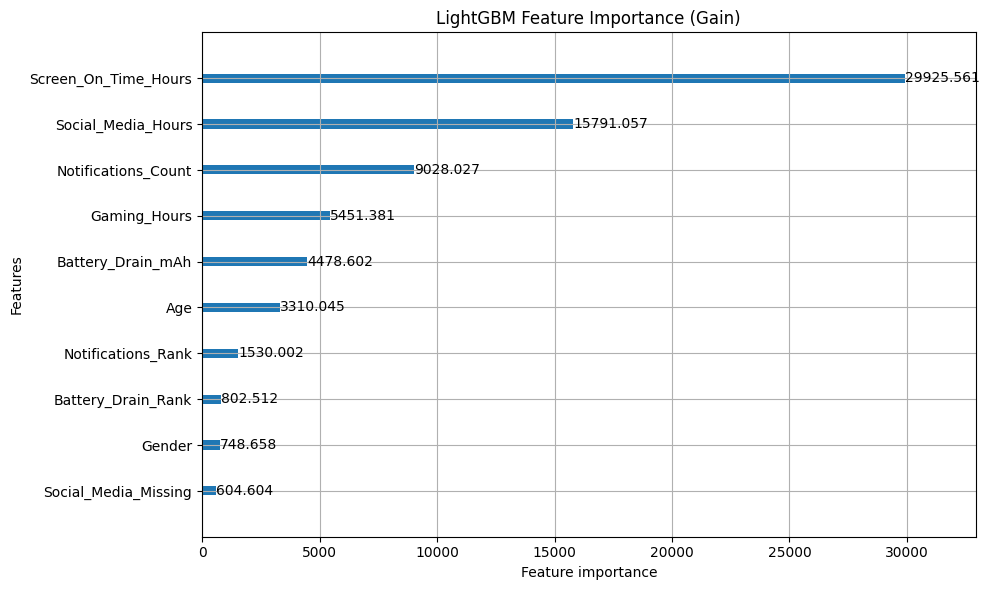

In [7]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
# Plotting importance from the first fold's LightGBM model
plot_importance(lgb_models[0], ax=ax, importance_type="gain", max_num_features=15, title="LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()

<br>

---

## 7. Level-1 Stacking Meta-Learner

Rather than adopting a simple uniform average, a `LogisticRegression` meta-learner evaluates the OOF prediction matrix to assign optimal continuous weights to each base learner, maximising the final validation AUC.

<br>

In [8]:
meta_learner = LogisticRegression(random_state=SEED)
meta_learner.fit(oof_matrix, train_feat[TARGET])

# Generate final blended OOF predictions
stack_oof_preds = meta_learner.predict_proba(oof_matrix)[:, 1]

# Generate final blended Test predictions
stack_test_preds = meta_learner.predict_proba(test_matrix)[:, 1]

# Tabulate validation results
results = []
for i, name in enumerate(models.keys()):
    auc = roc_auc_score(train_feat[TARGET], oof_matrix[:, i])
    results.append({"Architecture": f"L0: {name}", "CV AUC": auc})

results.append({"Architecture": "L1: Logistic Stacking", "CV AUC": roc_auc_score(train_feat[TARGET], stack_oof_preds)})

results_df = pd.DataFrame(results).set_index("Architecture")
display(results_df)

print("\nMeta-Learner Assigned Weights (Coefficients):")
for name, coef in zip(models.keys(), meta_learner.coef_[0]):
    print(f"  - {name}: {coef:.4f}")


/Users/amey/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/amey/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/amey/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/amey/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/amey/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/amey/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encounter

,CV AUC
Architecture,
L0: LightGBM,0.911777
L0: XGBoost,0.913414
L0: CatBoost,0.920230
L1: Logistic Stacking,0.920168



Meta-Learner Assigned Weights (Coefficients):
  - LightGBM: -0.3820
  - XGBoost: 0.7874
  - CatBoost: 5.3050


<br>

---

## 8. Submission Compilation

Verification checks validate vector dimensions, data types, and index parity against the required competition schema prior to export.

<br>

In [9]:
sub = sample_sub.copy()
sub[TARGET] = stack_test_preds

tb.check_submission(sub, sample_sub)

sub.to_csv("submission.csv", index=False)
print("Stacking ensemble predictions successfully saved to submission.csv.")

[toolbox] PASS: Row count (1000)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs
[toolbox] WARN: 'addicted_label' range [0.0507, 0.9414] far outside sample [0.5000, 0.5000]
[toolbox] All checks passed. Safe to submit.
Stacking ensemble predictions successfully saved to submission.csv.


<br>

---

<div align="center">

**Amey Thakur** &nbsp;·&nbsp; [Kaggle](https://www.kaggle.com/ameythakur20) &nbsp;·&nbsp; [GitHub](https://github.com/Amey-Thakur) &nbsp;·&nbsp; [ORCID](https://orcid.org/0000-0001-5644-1575)

<br>

[↑ Back to top](#predicting-smartphone-addiction)

</div>